In [2]:
import pandas

import pygsheets
import numpy
import re

# import data directly from google sheets

In [3]:
gc = pygsheets.authorize(service_account_env_var='GDRIVE_API_CREDENTIALS')
#spreadsheet = gc.open_by_key('1foPLE6K-uqFlaYgLPAUxzeXfDO5wOOqE7tibNHeqTek')
spreadsheet = gc.open_by_key('1FTF2QsKJQbya8qtgeUCSBDnE9NO4bgu_ADhMTe68oBI') # dashboard using dataset that was auto-archived on June 3 2024

gas_pipes = spreadsheet.worksheet('title','Gas pipelines').get_as_df(start='A3')
oil_pipes = spreadsheet.worksheet('title', 'Oil/NGL pipelines').get_as_df(start='A3')

#get country ratios sheet
country_ratios_df = spreadsheet.worksheet('title', 'Country ratios by pipeline').get_as_df()
region_df_orig = spreadsheet.worksheet('title', 'Country dictionary').get_as_df(start='A2')

In [4]:
fuel_type = 'Gas'
pipes_df_orig = gas_pipes.copy() #pandas.concat([gas_pipes, oil_pipes], ignore_index=True)

In [5]:
gas_fuel_options = ['Gas']
ngl_fuel_options = ['NGL', 
                    'NGL, oil products', 
                    'Oil, NGL', 
                    'Oil, NGL, naphtha']
oil_fuel_options = ['Oil', 
                    'Oil, NGL', 
                    'Oil, NGL, naphtha']

In [6]:
owners_df_orig = spreadsheet.worksheet('title', 'Pipeline operators/owners (1/3)').get_as_df(start='A2')
owners_df_orig = owners_df_orig.loc[owners_df_orig.ProjectID!='']
owners_df_orig = owners_df_orig.loc[owners_df_orig.Wiki!='']
owners_df = owners_df_orig.replace('',numpy.nan)

owner_parent_links_df = spreadsheet.worksheet('title', 'Owner–parent relationships (2/3)').get_as_df(start='A2')
# only keep the owners with a checked relationship
owner_parent_links_df = owner_parent_links_df.loc[owner_parent_links_df['Parent–Owner Relationship Checked?']=='yes']
owner_parent_links_df.replace('',numpy.nan,inplace=True)

parents_df = spreadsheet.worksheet('title', 'Parent metadata (3/3)').get_as_df(start='A2')
parents_df = parents_df.loc[parents_df.Parent!='']

owners_df.set_index('ProjectID', inplace=True)
owner_parent_links_df.set_index('Owner', inplace=True)
parents_df.set_index('Parent', inplace=True)

# ****************************************

## create list of owner and parent column names
owner_pct_col_names = []
owner_col_names = []

parent_pct_col_names = []
parent_col_names = []

for num in range(1,11+1):
    owner_pct_col = f'Owner{num}%'
    owner_pct_col_names.append(owner_pct_col)
    
    owner_col = f'Owner{num}'
    owner_col_names.append(owner_col)
    
    parent_pct_col = f'Parent{num}%'
    parent_pct_col_names.append(parent_pct_col)
    
    parent_col = f'Parent{num}'
    parent_col_names.append(parent_col)

# ****************************************
## fill in missing parent info by borrowing owner info
owners_FULL_set = owners_df[owner_col_names].stack().dropna().unique().tolist() # from owners_df
owners_researched_set = list(set(owner_parent_links_df.index.to_list()))#+['Unknown'] # only existing owners, plus 'Unknown'
owners_diff = list(set(owners_FULL_set)-set(owners_researched_set))
owners_diff.append('Unknown')

# update owner_parent_links_df with these extra owners
owner_parent_links_df = pandas.concat([owner_parent_links_df, pandas.DataFrame(index=owners_diff, columns=owner_parent_links_df.columns)])
owner_parent_links_df['Parent1'].loc[owners_diff] = owners_diff
owner_parent_links_df['Parent1%'].loc[owners_diff] = '100.00%'

# ****************************************
# update parents_df with these as well
# note countries will be unknkown...
parents_set = list(set(parents_df.index.to_list()))
parents_diff = list(set(owners_diff)-set(parents_set))
parents_diff.append('Unknown')
parents_df = pandas.concat([parents_df, pandas.DataFrame(numpy.nan, index=parents_diff, columns=parents_df.columns)])
parents_df.loc[parents_diff,'ParentHQCountry'] = 'Unknown'

/var/folders/fl/t07mc8053p33mn6mdmvp45580000gn/T/ipykernel_10983/2705967703.py:49: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  owner_parent_links_df['Parent1'].loc[owners_diff] = owners_diff
/var/folders/fl/t07mc8053p33mn6mdmvp45580000gn/T

In [7]:
status_list = ['proposed', 
               'construction', 
               'shelved', 
               'cancelled', 
               'operating', 
               'idle', 
               'mothballed', 
               'retired']
country_list = sorted(set(region_df_orig['Country'].tolist()))
region_list = sorted(set(region_df_orig['Region'].tolist()))
if '--' in region_list:
    region_list.remove('--')
subregion_list = sorted(set(region_df_orig['SubRegion'].tolist()))
if '--' in subregion_list:
    subregion_list.remove('--')

## replace "--" with NaN, removing empty rows

the dataset is structured to have -- wherever there's a lookup value that doesn't exist; replacing it with NaN (numpy.nan) allows pandas to treat it as a null value, which makes calculations much easier

In [8]:
# replace -- entries with NaN
pipes_df_orig = pipes_df_orig.replace('--', numpy.nan)
pipes_df_orig = pipes_df_orig[pipes_df_orig['PipelineName']!='']

missing_wiki_projectids = pipes_df_orig.loc[pipes_df_orig.Wiki==''].ProjectID.tolist()
pipes_df_orig = pipes_df_orig[pipes_df_orig['RouteAccuracy']!='']

country_ratios_df.replace('--', numpy.nan, inplace=True)
country_ratios_df = country_ratios_df.loc[~country_ratios_df.ProjectID.isin(missing_wiki_projectids)]

/var/folders/fl/t07mc8053p33mn6mdmvp45580000gn/T/ipykernel_10983/1305070219.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pipes_df_orig = pipes_df_orig.replace('--', numpy.nan)
/var/folders/fl/t07mc8053p33mn6mdmvp45580000gn/T/ipykernel_10983/1305070219.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  country_ratios_df.replace('--', numpy.nan, inplace=True)


# km by country, km by region calculations

In [9]:
dict_subregion_region = pandas.Series(region_df_orig.Region.values, index=region_df_orig.SubRegion).to_dict()
#dict_subregion_region

In [10]:
region_df_orig_cleaned = region_df_orig.loc[(region_df_orig.Region!='--')&
                                            (region_df_orig.SubRegion!='--')]
multiindex_region_subregion = region_df_orig_cleaned.groupby(['Region','SubRegion'])['Country'].count().index
multiindex_region_subregion_country = region_df_orig_cleaned.groupby(['Region','SubRegion','Country'])['Country'].count().index

In [11]:
country_ratios_fuel_df = country_ratios_df[country_ratios_df.Fuel.isin(gas_fuel_options)]

km_by_country_df = pandas.DataFrame(columns=status_list, index=country_list)
km_by_subregion_df = pandas.DataFrame(columns=status_list, index=multiindex_region_subregion)
km_by_region_df = pandas.DataFrame(columns=status_list, index=region_list)

print('===country-level calculations===')
for status in status_list:
    print(status)
    country_ratios_fuel_df_status = country_ratios_fuel_df[country_ratios_fuel_df['Status']==status]
    km_by_country_df[status] = country_ratios_fuel_df_status.groupby('Country')['LengthMergedKmByCountry'].sum()
    km_by_subregion_df[status] = country_ratios_fuel_df_status.groupby(['Region','SubRegion'])['LengthMergedKmByCountry'].sum()
    km_by_region_df[status] = country_ratios_fuel_df_status.groupby('Region')['LengthMergedKmByCountry'].sum()

# # fill NaN with 0.0
km_by_subregion_df = km_by_subregion_df.fillna(0)
km_by_country_df = km_by_country_df.fillna(0)
km_by_region_df = km_by_region_df.fillna(0)

#km_by_region_df.sort_index(level='Region', inplace=True)
#km_by_region_df = km_by_region_df.loc[~(km_by_region_df==0).all(axis=1)]

# total
# km_by_region_df.loc['Total',:] = km_by_region_df.sum(axis=0).values
# km_by_country_df.loc['Total',:] = km_by_country_df.sum(axis=0).values

km_by_subregion_df['proposed+construction'] = km_by_subregion_df[['proposed','construction']].sum(axis=1)
km_by_subregion_df = km_by_subregion_df[['proposed', 'construction', 'proposed+construction', 'shelved', 'cancelled', 'operating', 'idle', 'mothballed', 'retired']]

km_by_country_df['proposed+construction'] = km_by_country_df[['proposed','construction']].sum(axis=1)
km_by_country_df.sort_values('proposed+construction', ascending=False, inplace=True)
km_by_country_df = km_by_country_df.loc[~(km_by_country_df==0).all(axis=1)]
km_by_country_df.loc[:,'Region'] = region_df_orig.set_index('Country').loc[km_by_country_df.index.tolist()].Region
km_by_country_df.loc[:,'Subregion'] = region_df_orig.set_index('Country').loc[km_by_country_df.index.tolist()].SubRegion
km_by_country_df = km_by_country_df[['Region','Subregion','proposed', 'construction', 'proposed+construction', 'shelved', 'cancelled', 'operating', 'idle', 'mothballed', 'retired']]
km_by_country_df = km_by_country_df.loc[(km_by_country_df.Region!='--')&
                                        (km_by_country_df.Subregion!='--')]

km_by_region_df['proposed+construction'] = km_by_region_df[['proposed','construction']].sum(axis=1)
km_by_region_df = km_by_region_df[['proposed', 'construction', 'proposed+construction', 'shelved', 'cancelled', 'operating', 'idle', 'mothballed', 'retired']]

km_by_subregion_df.index.set_names(['Region','Subregion'], inplace=True)
km_by_subregion_df.loc['Total',:] = km_by_subregion_df.sum(axis=0).values
km_by_subregion_df.replace(0,'', inplace=False)

===country-level calculations===
proposed
construction
shelved
cancelled
operating
idle
mothballed
retired


proposed construction  \
Region   Subregion                                                 
Africa   Northern Africa                    5317.84       187.93   
         Sub-Saharan Africa                17317.21       1582.0   
Americas Latin America and the Caribbean   17142.28       2170.0   
         Northern America                    9418.7      2515.84   
Asia     Central Asia                       3867.14      1604.33   
         Eastern Asia                      45138.18      34764.8   
         South-eastern Asia                 8849.03       1087.3   
         Southern Asia                     12731.61     22425.64   
         Western Asia                       6015.84      2153.52   
Europe   Eastern Europe                    21580.93      3766.49   
         Northern Europe                     972.49          1.2   
         Southern Europe                    8312.03        869.0   
         Western Europe                       678.3         82.0   
Oceania  Australia and New Zealand          9856.64          4.3   
         Melanesia                            320.0                
         Micronesia                                                
         Polynesia                                                 
Total                                     167518.22     73214.35   

                                         proposed+construction   shelved  \
Region   Subregion                                                         
Africa   Northern Africa                               5505.77    172.21   
         Sub-Saharan Africa                           18899.21   1319.72   
Americas Latin America and the Caribbean              19312.28   3097.05   
         Northern America                             11934.54   3456.39   
Asia     Central Asia                                  5471.47             
         Eastern Asia                                 79902.98   1868.49   
         South-eastern Asia                            9936.33   2712.41   
         Southern Asia                                35157.25    1752.0   
         Western Asia                                  8169.36   1845.76   
Europe   Eastern Europe                               25347.42   4553.92   
         Northern Europe                                973.69    1000.0   
         Southern Europe                               9181.03    764.54   
         Western Europe                                  760.3     69.25   
Oceania  Australia and New Zealand                     9860.94   3726.22   
         Melanesia                                       320.0     400.0   
         Micronesia                                                        
         Polynesia                                                         
Total                                                240732.57  26737.96   

                                         cancelled   operating     idle  \
Region   Subregion                                                        
Africa   Northern Africa                     589.0     24859.7            
         Sub-Saharan Africa                 228.96     7141.52            
Americas Latin America and the Caribbean   2344.66    60457.65    331.0   
         Northern America                 20654.99   403409.71     50.0   
Asia     Central Asia                      2590.59    29099.48            
         Eastern Asia                      2827.37   139007.15            
         South-eastern Asia                 1329.0    17111.84            
         Southern Asia                    10509.97     39861.3            
         Western Asia                      9827.33    36975.93            
Europe   Eastern Europe                     8475.9   141349.78  1651.65   
         Northern Europe                   1003.77    25624.76            
         Southern Europe                   4436.09    27874.34            
         Western Europe                     2138.2    28615.96     8.35   
Oceania  Australia and New Zealand  

In [12]:
#km_by_country_df.to_excel('km-by-country-region-subregion.xlsx')
km_by_country_df

,Region,Subregion,proposed,construction,proposed+construction,shelved,cancelled,operating,idle,mothballed,retired
China,Asia,Eastern Asia,43781.58,34713.00,78494.58,815.53,1462.86,133773.87,0.00,0.0,114.40
Russia,Europe,Eastern Europe,18434.48,2901.93,21336.41,1246.65,4904.55,113126.94,414.27,1177.3,2000.58
India,Asia,Southern Asia,5573.68,15283.00,20856.68,1055.00,4671.05,19019.42,0.00,0.0,0.00
Australia,Oceania,Australia and New Zealand,9856.64,4.30,9860.94,3726.22,7214.68,28727.34,0.00,0.0,0.00
United States,Americas,Northern America,8084.29,1448.00,9532.29,3374.58,14090.73,341541.56,50.00,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...
Libya,Africa,Northern Africa,0.00,0.00,0.00,0.00,115.56,6243.07,0.00,0.0,0.00
Martinique,Americas,Latin America and the Caribbean,0.00,0.00,0.00,0.00,149.35,0.00,0.00,0.0,0.00
Luxembourg,Europe,Western Europe,0.00,0.00,0.00,0.00,0.00,150.95,0.00,0.0,0.00
Macao,Asia,Eastern Asia,0.00,0.00,0.00,0.00,0.00,12.80,0.00,0.0,0.00


# save km by country for dashboard

In [13]:
missing_countries = list(set(region_df_orig.Country.tolist())-set(km_by_country_df.index.tolist()))
# add empty missing rows so geometries will still be plotted in Flourish
for cntry in missing_countries:
    km_by_country_df.loc[cntry] = 0

# add 3 letter code for Flourish map
km_by_country_df['CountryISO3166-1alpha-3'] = region_df_orig.set_index('Country').loc[km_by_country_df.index,'CountryISO3166-1alpha-3']
km_by_country_df['Region'] = region_df_orig.set_index('Country').loc[km_by_country_df.index,'Region']
km_by_country_df['Subregion'] = region_df_orig.set_index('Country').loc[km_by_country_df.index,'SubRegion']
km_by_country_df.sort_values('construction', ascending=False).drop('Antarctica').replace(0,'').to_excel('km-by-country-region-subregion-sorted-by-construction.xlsx')
#km_by_country_df.sort_values('construction', ascending=False).drop('Antarctica').to_excel('km-by-country-region-subregion-sorted-by-construction.xlsx')

In [14]:
km_by_country_df

,Region,Subregion,proposed,construction,proposed+construction,shelved,cancelled,operating,idle,mothballed,retired,CountryISO3166-1alpha-3
China,Asia,Eastern Asia,43781.58,34713.00,78494.58,815.53,1462.86,133773.87,0.00,0.0,114.40,CHN
Russia,Europe,Eastern Europe,18434.48,2901.93,21336.41,1246.65,4904.55,113126.94,414.27,1177.3,2000.58,RUS
India,Asia,Southern Asia,5573.68,15283.00,20856.68,1055.00,4671.05,19019.42,0.00,0.0,0.00,IND
Australia,Oceania,Australia and New Zealand,9856.64,4.30,9860.94,3726.22,7214.68,28727.34,0.00,0.0,0.00,AUS
United States,Americas,Northern America,8084.29,1448.00,9532.29,3374.58,14090.73,341541.56,50.00,0.0,0.00,USA
...,...,...,...,...,...,...,...,...,...,...,...,...
Iceland,Europe,Northern Europe,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,ISL
Cayman Islands,Americas,Latin America and the Caribbean,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,CYM
Curaçao,Americas,Latin America and the Caribbean,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,CUW
Gibraltar,Europe,Southern Europe,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,GIB


# parent analysis

In [15]:
owner_parent_calculations_df = pandas.DataFrame()
# needs country, km in each country columns as well

for idx,row in country_ratios_df.loc[(country_ratios_df.Fuel.isin(gas_fuel_options))&
                                (country_ratios_df.Status.isin(['proposed','construction']))].iterrows():
    parent_string = pipes_df_orig.loc[pipes_df_orig.ProjectID==row.ProjectID].Parent.values[0]
    #print(parent_string)
    if parent_string == '--':
        parent_string = 'unknown [unknown %]'
    parent_list = re.sub(' \[.*?\]', '', parent_string).split('; ') # all entries must have an "Owner [%]" syntax, so [unknown %] is included
    percent_list = [float(i.rstrip('%'))/100. for i in re.findall('\\d+(?:\\.\\d+)?%', parent_string)]
    #print(percent_list)

    if parent_list.__len__()!=percent_list.__len__():
        if percent_list==[]:
            percent_list = [1/parent_list.__len__() for i in parent_list]
        else:
            nmissing = parent_list.__len__()-percent_list.__len__()
            # distribute nans evenly
            total = numpy.nansum(percent_list)
            leftover = 1-total
            percent_list += [leftover/nmissing]*nmissing

    # for when database isn't completely filled in for owners:
    for p_idx,parent in enumerate(parent_list):
        if parent not in parents_df.index.to_list():
            parents_df.loc[parent,'ParentHQCountry']='unknown'
        owner_parent_calculations_df = pandas.concat([owner_parent_calculations_df, 
                                                      pandas.DataFrame([{'Parent':parent, 'ProjectID':row.ProjectID, 
                                                                         'FractionOwnership':percent_list[p_idx],
                                                                         'ParentHQCountry':parents_df.loc[parents_df.index==parent]['ParentHQCountry'].values[0],
                                                                         'PipelineCountry':row.Country,
                                                                         'Status':row.Status,
                                                                         'LengthMergedKmByCountry':row.LengthMergedKmByCountry,
                                                                         'LengthMergedKmByPipeline':row.LengthMergedKmByPipeline,
                                                                         'CapacityBOEd':row.CapacityBOEd}])])

owner_parent_calculations_df['KmOwnershipByCountry'] = owner_parent_calculations_df.FractionOwnership*owner_parent_calculations_df.LengthMergedKmByCountry

## print out leading parent companies

In [16]:
parent_country_km_df = \
owner_parent_calculations_df.loc[#(owner_parent_calculations_df.PipelineCountry.isin(region_df_touse.Country.tolist()))&
                                 (owner_parent_calculations_df.Status.isin(['proposed','construction']))]

parent_country_km_df_table = pandas.DataFrame(index=parent_country_km_df.Parent.unique().tolist(),
                                             columns=['Pipeline Country Locations','Owner Headquarters Country',
                                                      'proposed','construction','In Development (proposed + construction)','ProjectIDs'])

parent_country_km_df_table['proposed'] = parent_country_km_df.loc[parent_country_km_df.Status=='proposed'].groupby('Parent').sum('KmOwnershipByCountry')[['KmOwnershipByCountry']]
parent_country_km_df_table['construction'] = parent_country_km_df.loc[parent_country_km_df.Status=='construction'].groupby('Parent').sum('KmOwnershipByCountry')[['KmOwnershipByCountry']]

parent_country_km_df_table = parent_country_km_df_table.loc[parent_country_km_df_table.index!='']

In [20]:
# top n parents
n=21

In [24]:
country_agg_df = pandas.DataFrame(owner_parent_calculations_df.groupby(['Parent']).PipelineCountry.agg(lambda x: ', '.join(x.unique())))
projectid_agg_df = pandas.DataFrame(owner_parent_calculations_df.groupby(['Parent']).ProjectID.agg(lambda x: ', '.join(x.unique())))
parent_country_km_df_table['Pipeline Country Locations'] = country_agg_df.PipelineCountry
parent_country_km_df_table['Number of Projects'] = owner_parent_calculations_df.groupby(['Parent']).ProjectID.count()
parent_country_km_df_table['ProjectIDs'] = projectid_agg_df.ProjectID
parent_country_km_df_table['Owner Headquarters Country'] = parent_country_km_df.drop_duplicates('Parent').set_index('Parent').ParentHQCountry
parent_country_km_df_table['In Development (proposed + construction)'] = parent_country_km_df_table[['proposed','construction']].sum(axis=1, min_count=0)
#parent_country_km_df_table.loc[~parent_country_km_df_table.index.isin(['Not in database','Unknown'])].replace(numpy.nan, 0).sort_values('In Development (proposed + construction)', ascending=False)[:n].to_excel('parent-country-km-table.xlsx')
parent_country_km_df_table.loc[~parent_country_km_df_table.index.isin(['Not in database','unknown','other'])].replace(numpy.nan, 0).sort_values('In Development (proposed + construction)', ascending=False)[:n]

to_save = parent_country_km_df_table.loc[~parent_country_km_df_table.index.isin(['Not in database','unknown','other','PipeChina','国家石油天然气管网集团有限公司'])].replace(numpy.nan, 0).sort_values('In Development (proposed + construction)', ascending=False)[:n]
to_save.to_excel('parent-country-km-table-for-dashboard.xlsx')


# fluvial owner plot for dashboard

In [86]:
top_n_parents_df = parent_country_km_df_table.drop('unknown').sort_values('In Development (proposed + construction)', ascending=False)[:n]

In [87]:
top_n_parents_df['In Development (proposed + construction)'].sum()/parent_country_km_df_table['In Development (proposed + construction)'].sum()

0.46881175735376523

In [88]:
top_n_parents_list = top_n_parents_df.index.tolist()

In [89]:
owner_parent_calculations_df.loc[(owner_parent_calculations_df.Parent.isin(top_n_parents_list))&
                                (owner_parent_calculations_df.Status.isin(['proposed','construction']))][['Parent',
                                                                                                          'ParentHQCountry',
                                                                                                          'PipelineCountry',
                                                                                                          'Status',
                                                                                                          'LengthMergedKmByCountry']].replace({'proposed':'Proposed','construction':'Construction'}).to_excel(f'parent-fluvial-diagram-top-{n}.xlsx')

# cost estimates (pipeline cost per km)

## pick out high and low quantiles

In [90]:
temp_df = pipes_df_orig.loc[(~pipes_df_orig.CostUSDPerKm.isnull())&
                            (pipes_df_orig.Fuel.isin(gas_fuel_options))]
qlo_val = 0.025
qhi_val = 0.975

q_lo=temp_df['CostUSDPerKm'].quantile(qlo_val)
q_hi=temp_df['CostUSDPerKm'].quantile(qhi_val)
print(temp_df['CostUSDPerKm'].quantile(qlo_val))
print(temp_df['CostUSDPerKm'].quantile(qhi_val))

temp_df = temp_df.loc[temp_df['CostUSDPerKm'].between(q_lo, q_hi, inclusive='neither')]

153532.33132
16666666.67


In [91]:
# pull out only pipelines that have a KNOWN length AND a cost
country_ratios_with_length_and_cost_df = country_ratios_df.loc[(country_ratios_df.Fuel.isin(gas_fuel_options)) & 
                                                               (country_ratios_df['CostUSDPerKm'].notna()) & 
                                                               (country_ratios_df['LengthKnownKmByCountry'].notna()) #&
                                                               #(country_ratios_df['LengthKnownKm']!=0) &
                                                               #(country_ratios_df['CostUSDPerKm']<10e6)
                                                              ]

country_ratios_with_length_and_cost_df = country_ratios_with_length_and_cost_df.loc[
    country_ratios_with_length_and_cost_df['CostUSDPerKm'].between(q_lo, q_hi, inclusive='neither')]
#country_ratios_with_length_and_cost_df = country_ratios_with_length_and_cost_df[~country_ratios_with_length_and_cost_df.ProjectID.isin(outliers_projectids)]

In [92]:
country_ratios_df.loc[(country_ratios_df.Fuel.isin(gas_fuel_options)) & 
                    (country_ratios_df['CostUSDPerKm'].notna()) & 
                    (country_ratios_df['LengthKnownKmByCountry'].notna())].shape

(1138, 36)

In [93]:
country_ratios_df.loc[(country_ratios_df.Fuel.isin(gas_fuel_options))].shape

(3999, 36)

### global mean value

In [94]:
global_mean = country_ratios_with_length_and_cost_df['CostUSDPerKm'].drop_duplicates().mean()
country_ratios_with_length_and_cost_df['CostUSDPerKm'].drop_duplicates().mean()

2316887.2335619465

### calculate regional costs

In [95]:
region_list

['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']

In [96]:
pipes_costs_region_df = pandas.DataFrame(0, index=region_list, columns=['CostUSDPerKm','DataPoints'])#,'NumberOfLengths'])

for region in region_list:
    country_ratios_region_df = country_ratios_with_length_and_cost_df.loc[country_ratios_with_length_and_cost_df['Region']==region,:]
    pipes_costs_region_df.loc[region,'CostUSDPerKm'] = country_ratios_region_df['CostUSDPerKm'].mean()
    pipes_costs_region_df.loc[region,'DataPoints'] = list(set(country_ratios_region_df['ProjectID'])).__len__()
    

/var/folders/fl/t07mc8053p33mn6mdmvp45580000gn/T/ipykernel_33494/466907183.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3096054.8' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pipes_costs_region_df.loc[region,'CostUSDPerKm'] = country_ratios_region_df['CostUSDPerKm'].mean()


In [97]:
pipes_costs_subregion_df = pandas.DataFrame(0, index=subregion_list, columns=['CostUSDPerKm','DataPoints'])#,'NumberOfLengths'])

for subregion in subregion_list:
    country_ratios_subregion_df = country_ratios_with_length_and_cost_df.loc[country_ratios_with_length_and_cost_df['SubRegion']==subregion,:]
    n_datapoints = list(set(country_ratios_subregion_df['ProjectID'])).__len__()
    if n_datapoints < 3:
        pipes_costs_subregion_df.loc[subregion,'DataPoints'] = list(set(country_ratios_subregion_df['ProjectID'])).__len__()
        pipes_costs_subregion_df.loc[subregion,'CostUSDPerKm'] = pipes_costs_region_df.loc[dict_subregion_region[subregion],'CostUSDPerKm']
    else:
        pipes_costs_subregion_df.loc[subregion,'DataPoints'] = list(set(country_ratios_subregion_df['ProjectID'])).__len__()
        pipes_costs_subregion_df.loc[subregion,'CostUSDPerKm'] = country_ratios_subregion_df['CostUSDPerKm'].mean()

pipes_costs_subregion_df.sort_values('CostUSDPerKm', ascending=False)

/var/folders/fl/t07mc8053p33mn6mdmvp45580000gn/T/ipykernel_33494/2437797586.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2847723.311764706' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pipes_costs_subregion_df.loc[subregion,'CostUSDPerKm'] = country_ratios_subregion_df['CostUSDPerKm'].mean()


,CostUSDPerKm,DataPoints
Northern Europe,5.757915e+06,10
Western Europe,4.763445e+06,13
Northern America,4.591099e+06,178
Sub-Saharan Africa,3.928709e+06,5
Western Asia,3.638304e+06,39
Latin America and the Caribbean,3.251561e+06,44
Melanesia,2.847723e+06,0
Micronesia,2.847723e+06,0
Polynesia,2.847723e+06,0
Australia and New Zealand,2.847723e+06,17


In [98]:
pipes_costs_region_df

,CostUSDPerKm,DataPoints
Africa,3.096055e+06,29
Americas,4.314966e+06,216
Asia,1.677597e+06,561
Europe,2.911999e+06,130
Oceania,2.847723e+06,17


In [99]:
country_ratios_region_df['CostUSDPerKm'].mean()

2847723.311764706

In [100]:
pandas.options.display.float_format = '{:,.3f}'.format
temp_df = pipes_costs_region_df.copy()
temp_df['CostUSDPerKm'] = temp_df['CostUSDPerKm']/1e6
temp_df.sort_values('CostUSDPerKm', ascending=False)#.loc[region]['CostUSDPerKm']

,CostUSDPerKm,DataPoints
Americas,4.315,216
Africa,3.096,29
Europe,2.912,130
Oceania,2.848,17
Asia,1.678,561


In [101]:
pandas.options.display.float_format = '{:,.3f}'.format
temp_df = pipes_costs_subregion_df.copy()
temp_df['CostUSDPerKm'] = temp_df['CostUSDPerKm']/1e6
temp_df.sort_values('CostUSDPerKm', ascending=False)#.loc[region]['CostUSDPerKm']

,CostUSDPerKm,DataPoints
Northern Europe,5.758,10
Western Europe,4.763,13
Northern America,4.591,178
Sub-Saharan Africa,3.929,5
Western Asia,3.638,39
Latin America and the Caribbean,3.252,44
Melanesia,2.848,0
Micronesia,2.848,0
Polynesia,2.848,0
Australia and New Zealand,2.848,17


# tables etc.

## table for stranded asset calculations

## country-level capex estimates

In [102]:
country_ratios_df_specific_fuel = country_ratios_df.loc[country_ratios_df.Fuel.isin(gas_fuel_options)]
country_ratios_df_specific_fuel.reset_index(drop=True, inplace=True)
country_ratios_df_specific_fuel.loc[:,'CostUSDEstimate'] = numpy.nan

for idx,row in country_ratios_df_specific_fuel.iterrows():
    # calculate cost
    cntry = row.Country
    #region = row.Region
    subregion = row.SubRegion
    km_by_cntry = row.LengthMergedKmByCountry
    #country_ratios_df.loc[idx,'CostUSDEstimate'] = pipes_costs_region_df.loc[region, 'CostUSDPerKm'] * km_by_cntry
    country_ratios_df_specific_fuel.loc[idx,'CostUSDEstimate'] = pipes_costs_subregion_df.loc[subregion, 'CostUSDPerKm'] * km_by_cntry

# replace any known costs now
country_ratios_df_specific_fuel.loc[(~country_ratios_df_specific_fuel.LengthKnownKmByCountry.isna())&
                    (~country_ratios_df_specific_fuel.CostUSDPerKm.isna()),'CostUSDEstimate'] = \
country_ratios_df_specific_fuel.loc[(~country_ratios_df_specific_fuel.LengthKnownKmByCountry.isna())&
                    (~country_ratios_df_specific_fuel.CostUSDPerKm.isna()), 'LengthMergedKmByCountry'] * \
country_ratios_df_specific_fuel.loc[(~country_ratios_df_specific_fuel.LengthKnownKmByCountry.isna())&
                    (~country_ratios_df_specific_fuel.CostUSDPerKm.isna()), 'CostUSDPerKm']

/var/folders/fl/t07mc8053p33mn6mdmvp45580000gn/T/ipykernel_33494/238730790.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  country_ratios_df_specific_fuel.loc[:,'CostUSDEstimate'] = numpy.nan


In [103]:
country_ratios_df_specific_fuel.SubRegion.unique()

array(['Northern America', 'Latin America and the Caribbean',
       'Western Asia', 'Northern Africa', 'Sub-Saharan Africa',
       'Southern Europe', 'Southern Asia', 'Western Europe',
       'Australia and New Zealand', 'Eastern Europe', 'Northern Europe',
       'Central Asia', 'Eastern Asia', 'South-eastern Asia', 'Melanesia'],
      dtype=object)

In [104]:
capex_by_country_df = pandas.DataFrame(columns=status_list, index=country_list)
capex_by_region_df = pandas.DataFrame(columns=status_list, index=region_list)
capex_by_subregion_df = pandas.DataFrame(columns=status_list, index=multiindex_region_subregion)

print('===country-level calculations===')
for status in status_list:
    print(status)
    country_ratios_df_specific_fuel_status = country_ratios_df_specific_fuel.loc[country_ratios_df_specific_fuel.Status==status]
    country_ratios_df_specific_fuel_status = country_ratios_df_specific_fuel_status.loc[~country_ratios_df_specific_fuel_status.SubRegion.isnull()]
    capex_by_country_df[status] = country_ratios_df_specific_fuel_status.groupby('Country')['CostUSDEstimate'].sum()/1e9
    capex_by_region_df[status] = country_ratios_df_specific_fuel_status.groupby('Region')['CostUSDEstimate'].sum()/1e9
    capex_by_subregion_df[status] = country_ratios_df_specific_fuel_status.groupby(['Region','SubRegion'])['CostUSDEstimate'].sum()/1e9

# # fill NaN with 0.0
capex_by_region_df = capex_by_region_df.fillna(0)
capex_by_country_df = capex_by_country_df.fillna(0)
capex_by_subregion_df = capex_by_subregion_df.fillna(0)

capex_by_region_df['proposed+construction'] = capex_by_region_df[['proposed','construction']].sum(axis=1)
capex_by_region_df = capex_by_region_df[['proposed', 'construction', 'proposed+construction', 'shelved', 'cancelled', 'operating', 'idle', 'mothballed', 'retired']]
# capex_by_region_df.loc['Total',:] = capex_by_region_df.sum(axis=0).values

capex_by_country_df['proposed+construction'] = capex_by_country_df[['proposed','construction']].sum(axis=1)
capex_by_country_df = capex_by_country_df[['proposed', 'construction', 'proposed+construction', 'shelved', 'cancelled', 'operating', 'idle', 'mothballed', 'retired']]
#capex_by_country_df.sort_values('construction', ascending=False, inplace=True)
# capex_by_country_df.loc['Total',:] = capex_by_country_df.sum(axis=0).values

capex_by_subregion_df['proposed+construction'] = capex_by_subregion_df[['proposed','construction']].sum(axis=1)
capex_by_subregion_df = capex_by_subregion_df[['proposed', 'construction', 'proposed+construction', 'shelved', 'cancelled', 'operating', 'idle', 'mothballed', 'retired']]
# capex_by_subregion_df.loc['Total',:] = capex_by_subregion_df.sum(axis=0).values

===country-level calculations===
proposed
construction
shelved
cancelled
operating
idle
mothballed
retired


# save capex by country for dashboard

In [105]:
missing_countries = list(set(region_df_orig.Country.tolist())-set(capex_by_country_df.index.tolist()))
# add empty missing rows so geometries will still be plotted in Flourish
for cntry in missing_countries:
    capex_by_country_df.loc[cntry] = 0

# add 3 letter code for Flourish map
capex_by_country_df['CountryISO3166-1alpha-3'] = region_df_orig.set_index('Country').loc[capex_by_country_df.index,'CountryISO3166-1alpha-3']
# add regions, subregions
capex_by_country_df['Region'] = region_df_orig.set_index('Country').loc[capex_by_country_df.index,'Region']
capex_by_country_df['Subregion'] = region_df_orig.set_index('Country').loc[capex_by_country_df.index,'SubRegion']

#capex_by_country_df.sort_values('proposed+construction', ascending=False).to_excel('capex-by-country-sorted-by-in-dev.xlsx')

In [106]:
capex_by_country_df

,proposed,construction,proposed+construction,shelved,cancelled,operating,idle,mothballed,retired,CountryISO3166-1alpha-3,Region,Subregion
Afghanistan,3.495,0.214,3.709,0.000,0.000,0.000,0.000,0.000,0.000,AFG,Asia,Southern Asia
Albania,0.352,0.000,0.352,0.000,0.199,1.538,0.000,0.000,0.000,ALB,Europe,Southern Europe
Algeria,7.998,0.000,7.998,0.464,0.833,29.098,0.000,1.458,0.000,DZA,Africa,Northern Africa
American Samoa,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,ASM,Oceania,Polynesia
Andorra,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,AND,Europe,Southern Europe
...,...,...,...,...,...,...,...,...,...,...,...,...
Western Sahara,3.491,0.000,3.491,0.000,0.000,0.000,0.000,0.000,0.000,ESH,Africa,Northern Africa
Yemen,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,YEM,Asia,Western Asia
Zambia,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,ZMB,Africa,Sub-Saharan Africa
Zimbabwe,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,ZWE,Africa,Sub-Saharan Africa


In [107]:
capex_by_subregion_df.index = capex_by_subregion_df.index.set_names(['Region','Subregion'])
capex_by_subregion_df.replace(0,'')

proposed construction  \
Region   Subregion                                               
Africa   Northern Africa                   19.000        0.261   
         Sub-Saharan Africa                68.295        3.998   
Americas Latin America and the Caribbean   62.000        6.539   
         Northern America                  48.871       19.915   
Asia     Central Asia                       9.228        7.618   
         Eastern Asia                      60.753       54.998   
         South-eastern Asia                18.300        3.034   
         Southern Asia                     37.909       40.127   
         Western Asia                      19.887        7.637   
Europe   Eastern Europe                    54.399        9.155   
         Northern Europe                    4.178        0.007   
         Southern Europe                   18.295        1.077   
         Western Europe                     3.044        0.391   
Oceania  Australia and New Zealand         24.958        0.049   
         Melanesia                          0.911                
         Micronesia                                              
         Polynesia                                               

                                         proposed+construction shelved  \
Region   Subregion                                                       
Africa   Northern Africa                                19.261   0.600   
         Sub-Saharan Africa                             72.293   5.185   
Americas Latin America and the Caribbean                68.539   8.126   
         Northern America                               68.786  20.092   
Asia     Central Asia                                   16.846           
         Eastern Asia                                  115.750   2.588   
         South-eastern Asia                             21.333   7.717   
         Southern Asia                                  78.036   4.249   
         Western Asia                                   27.524   7.518   
Europe   Eastern Europe                                 63.554   8.259   
         Northern Europe                                 4.185   0.400   
         Southern Europe                                19.372   2.472   
         Western Europe                                  3.435   0.241   
Oceania  Australia and New Zealand                      25.006   6.835   
         Melanesia                                       0.911   1.139   
         Micronesia                                                      
         Polynesia                                                       

                                         cancelled operating  idle mothballed  \
Region   Subregion                                                              
Africa   Northern Africa                     1.103    67.191            2.939   
         Sub-Saharan Africa                  0.900    28.057                    
Americas Latin America and the Caribbean     6.757   194.657 1.076      0.728   
         Northern America                  145.634 1,802.574 0.230              
Asia     Central Asia                        4.849    67.446            1.295   
         Eastern Asia                        8.073   215.827                    
         South-eastern Asia                  3.244    41.759                    
         Southern Asia                      23.922    87.008                    
         Western Asia                       35.755   136.874            3.063   
Europe   Eastern Europe                     28.403   471.317 4.277      9.215   
         Northern Europe                     5.780   145.399           21.973   
         Southern Europe                    14.193    71.445            0.587   
         Western Europe                      8.868   136.290 0.040      1.852   
Oceania  Australia and New Zealand          17.132    85.726                    
         Melanesia                           0.857     2.039                    
  

## sort into categories for capex map

<Axes: ylabel='Frequency'>

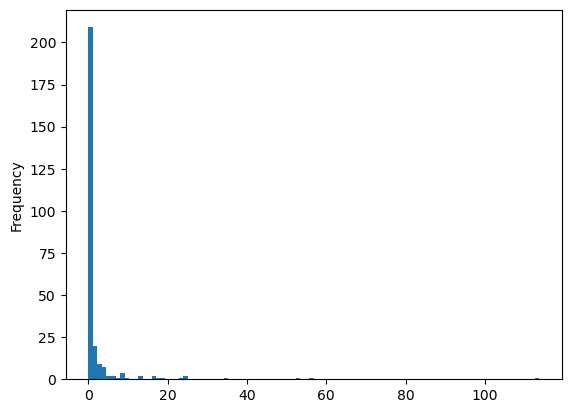

In [108]:
capex_by_country_df['proposed+construction'].plot.hist(bins=100)

In [109]:
capex_by_country_df['proposed+construction'].describe()

count   268.000
mean      2.257
std       9.225
min       0.000
25%       0.000
50%       0.000
75%       0.848
max     113.737
Name: proposed+construction, dtype: float64

In [127]:
#bins = [0,0.05,0.1,0.2,0.3,0.4,0.5,1,2,3,4,5,10,15,20,25,30]
bins = [0,1,5,10,50,150]
# create names for these bins, add an empty one up front
category_names = ['']+[f'US${str(bins[i])}–{str(bins[i+1])} billion' for i in range(bins.__len__()-1)]

# sort values into bins
bin_indices = numpy.digitize(capex_by_country_df['proposed+construction'].values, bins) # starts at 1

capex_by_country_df['proposed+construction bins'] = numpy.array(category_names)[bin_indices]

capex_by_country_df.sort_values('proposed+construction', ascending=False).to_excel('capex-by-country-sorted-by-in-dev-binned.xlsx')

# how much per year

In [111]:
pipes_started = pipes_df_orig.loc[(pipes_df_orig.Status=='operating') & 
                                    (pipes_df_orig.Fuel.isin(gas_fuel_options))]
pipes_started_sum = pipes_started.groupby('StartYearEarliest')['LengthMergedKm'].sum()


pipes_proposed = pipes_df_orig.loc[(pipes_df_orig.Status=='proposed') & 
                                    (pipes_df_orig.Fuel.isin(gas_fuel_options))]
pipes_proposed_sum = pipes_proposed.groupby('ProposalYear')['LengthMergedKm'].sum()


pipes_construction = pipes_df_orig.loc[(pipes_df_orig.Status=='construction') & 
                                    (pipes_df_orig.Fuel.isin(gas_fuel_options))]
pipes_construction_sum = pipes_construction.groupby('ConstructionYear')['LengthMergedKm'].sum()

In [117]:
if fuel_type == 'Gas':
    km_by_start_year = pandas.DataFrame(index=list(range(1980,2025)), columns=['Gas pipeline km'])
    km_by_start_year.index.name = 'Start year'
    km_by_start_year['Gas pipeline km'] = pipes_started_sum
    km_by_start_year['Gas pipeline km construction'] = pipes_construction_sum
    km_by_start_year['Gas pipeline km proposed'] = pipes_proposed_sum
    km_by_start_year.replace(numpy.nan,0,inplace=True)

if fuel_type == 'Oil':
    km_by_start_year = pandas.DataFrame(index=list(range(1980,2025)))
    km_by_start_year.index.name = 'Start year'
    km_by_start_year['Oil pipeline km operating'] = pipes_started_sum
    km_by_start_year['Oil pipeline km construction'] = pipes_construction_sum
    km_by_start_year['Oil pipeline km proposed'] = pipes_proposed_sum
    km_by_start_year.replace(numpy.nan,0,inplace=True)

if fuel_type == 'NGL':
    km_by_start_year = pandas.DataFrame(index=list(range(1980,2025)), columns=['NGL pipeline km'])
    km_by_start_year.index.name = 'Start year'
    km_by_start_year['NGL pipeline km'] = pipes_started_sum
    km_by_start_year.replace(numpy.nan,0,inplace=True)

km_by_start_year.loc['Total',:] = km_by_start_year.sum(axis=0)

km_by_start_year.to_excel('km-by-start-year.xlsx')
#km_by_start_year

# numbers for dashboard

## total operating in world

In [113]:
country_ratios_fuel_df.loc[country_ratios_fuel_df.Status.isin(['operating'])].LengthMergedKmByCountry.sum()

1013346.46

## came online this past year?

In [114]:
country_ratios_fuel_df.loc[(country_ratios_fuel_df.Status.isin(['operating'])) &
                            (country_ratios_fuel_df.StartYearEarliest==2023)].LengthMergedKmByCountry.sum()

3651.4100000000003

## in dev in past 5 years

In [115]:
country_ratios_fuel_df.loc[(country_ratios_fuel_df.Status.isin(['proposed','construction'])) &
                            (
                                country_ratios_fuel_df.ProposalYear.isin(list(range(2019,2024))) |
                                country_ratios_fuel_df.ConstructionYear.isin(list(range(2019,2024)))
                            )].LengthMergedKmByCountry.sum()

85216.39

## shelved or cancelled in past 5 years

In [116]:
# shelved or cancelled in past 5 years (2019–2023)
country_ratios_fuel_df.loc[(country_ratios_fuel_df.Status.isin(['shelved','cancelled'])) &
                            (
                                country_ratios_fuel_df.ShelvedYear.isin(list(range(2019,2024))) |
                                country_ratios_fuel_df.CancelledYear.isin(list(range(2019,2024)))
                            )].LengthMergedKmByCountry.sum()

24019.850000000002